In [22]:
%load_ext autoreload
%autoreload 2
%load_ext rpy2.ipython

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [23]:
import ibis
import pandas as pd

import src
from src.load import DataLoader

ibis.options.interactive = True
r_colormap_channel = src.r_colormap_name
r_colormap_party = src.r_colormap_party
r_out = str(src.OUT)
pd.options.display.float_format = "{:.1f}".format

In [24]:
%%R -i r_colormap_channel -i r_colormap_party -i r_out

suppressMessages(library(tidyverse))
library(ggplot2)
library(ggeffects)
library(here)
library(ggpubr)
library(patchwork)

options(scipen = 999)

cmap <- setNames(r_colormap_channel$color, r_colormap_channel$channel)
pmap <- setNames(r_colormap_party$color, r_colormap_party$party)

# Load Data

In [25]:
dl = DataLoader()

videos = dl.channels().join(dl.videos(filtered=True), "channel_id").to_pandas()

sentences = (
    dl.sentences(filtered=True)
    .join(dl.popbert(filtered=False), "sentence_id")
    .to_pandas()
)

sents = sentences.groupby("video_id", observed=True).agg(
    n_sents=("video_id", "size"),
    n_elite=("elite", "sum"),
    n_pplcentr=("pplcentr", "sum"),
    avg_elite=("elite", "mean"),
    avg_pplcentr=("pplcentr", "mean"),
)

# Dataset Summary Table

In [26]:
channel_overview = (
    videos.loc[videos.video_was_live == False]
    .merge(sents, on="video_id", how="left")
    .groupby("channel", observed=True)
    .agg(
        chFollowers=("channel_follower_count", "first"),
        chName=("channel_uploader_id", "first"),
        nShortVids=("video_is_short", lambda x: (x == 1).sum()),
        nLongVids=("video_is_short", lambda x: (x == 0).sum()),
        nVids=("video_was_live", lambda x: (x == 0).sum()),
        nLikesNA=("video_likes", lambda x: x.isna().sum()),
        meanViews=("video_views", "mean"),
        medianViews=("video_views", "median"),
        meanLikes=("video_likes", "mean"),
        medianLikes=("video_likes", "median"),
        meanVidLen=("video_duration", "mean"),
        nSentences=("n_sents", "sum"),
        first_video=("video_datetime_upload", "min"),
        latest_video=("video_datetime_upload", "max"),
    )
)

In [27]:
inlines = src.OUT / "manuscript/inlines"
inlines.mkdir(exist_ok=True)

In [28]:
# number of broken transcripts

broken_transcripts = dl.broken_transcripts(filtered=True).to_pandas()
n_broken = len(broken_transcripts)

n_broken = f"{n_broken:,.0f}"
p = inlines / "n_broken.txt"
p.unlink(missing_ok=True)
p.write_text(n_broken)
print(f"faulty transcripts: {n_broken}")

faulty transcripts: 142


In [29]:
# sum of durations

sum_of_seconds = videos.video_duration.sum()
hour_duration = f"{round(sum_of_seconds / 60 / 60, 1):,.1f}"
p = inlines / "sum_duration.txt"
p.unlink(missing_ok=True)
p.write_text(hour_duration)
print(f"Total sum of video durations: {hour_duration} hours")

Total sum of video durations: 2,337.0 hours


In [30]:
# number of videos

count_videos = len(videos)
count_videos = f"{count_videos:,.0f}"
p = inlines / "n_videos.txt"
p.unlink(missing_ok=True)
p.write_text(count_videos)
print(f"Total number of valid videos: {count_videos}")

Total number of valid videos: 19,060


In [31]:
# number of sentencs

count_sents = len(sentences)
count_sents = f"{count_sents:,.0f}"
p = inlines / "n_sents.txt"
p.unlink(missing_ok=True)
p.write_text(count_sents)
print(f"Total number of valid sentences: {count_sents}")

Total number of valid sentences: 1,281,590


In [32]:
summary_table = channel_overview.drop(["first_video", "latest_video"], axis=1)

summary_table

,chFollowers,chName,nShortVids,nLongVids,nVids,nLikesNA,meanViews,medianViews,meanLikes,medianLikes,meanVidLen,nSentences
channel,,,,,,,,,,,,
AfD BT,539000,@AfDFraktionimBundestag,648,5562,6210,0,54144.4,16631.0,4401.5,2060.0,412.4,378258
AfD DE,340000,@AfDTV,604,1245,1849,108,53807.9,19720.0,4376.2,2555.0,555.0,173264
CDU DE,30800,@cdutv,533,322,855,1,20565.5,1366.0,200.2,29.0,552.6,74302
CDU/CSU BT,8050,@cducsu,420,281,701,599,2083.4,254.0,140.4,25.0,624.7,60613
CSU BT,4930,@csuimbundestag9622,14,394,408,408,6222.3,319.5,NaN,NaN,350.4,20451
CSU DE,6890,@csumedia,113,69,182,4,25333.2,987.5,44.8,25.5,415.2,13745
FDP BT,24500,@fdpbt,288,346,634,1,22455.2,1675.5,291.3,59.0,385.3,39182
FDP DE,29600,@FDP,392,325,717,716,23456.1,1233.0,104.0,104.0,555.9,57304
Greens BT,3000,@gruenebundestag,127,93,220,0,4124.2,943.0,56.3,17.0,350.7,11520


In [33]:
path = src.OUT / "tables/channel_summary.csv"
path.unlink(missing_ok=True)

summary_table[
    [
        "chName",
        "chFollowers",
        "nVids",
        "meanViews",
        "medianViews",
    ]
].assign(
    meanViews=summary_table["meanViews"].round(2).apply(lambda x: f"{x:.2f}"),
    medianViews=summary_table["medianViews"].round(0).astype(int),
).rename(
    columns={
        "chName": "Channel ID",
        "chFollowers": "Followers",
        "channel": "Channel",
        "nVids": "N Videos",
        "meanViews": "Average Views",
        "medianViews": "Median Views",
    }
).to_csv(path)

In [34]:
path = src.OUT / "tables/videos_per_channel.csv"
path.unlink(missing_ok=True)
summary_table[
    [
        "nShortVids",
        "nLongVids",
        "nVids",
        "meanVidLen",
    ]
].to_csv(path)

In [35]:
path = src.OUT / "tables/channel_descriptives.csv"
path.unlink(missing_ok=True)
summary_table[
    [
        "chName",
        "chFollowers",
    ]
].to_csv(path)

In [36]:
path = src.OUT / "tables/video_descriptives_per_channel.csv"
path.unlink(missing_ok=True)
summary_table[
    ["meanViews", "medianViews", "meanLikes", "medianLikes", "nSentences"]
].fillna(
    "NA",
).to_csv(path)

# T-Test for Populism

In [37]:
from scipy.stats import levene
from scipy.stats import ttest_ind

In [38]:
df = (
    videos.loc[videos.video_was_live == False]
    .merge(sents, on="video_id", how="left")
    .groupby("video_id", observed=True)
    .agg(
        party=("party", "first"),
        avg_elite=("avg_elite", "mean"),
        avg_pplcentr=("avg_pplcentr", "mean"),
    )
)

populist = df.loc[df.party.isin(["AfD", "Left"]), ["avg_elite", "avg_pplcentr"]]
others = df.loc[~df.party.isin(["AfD", "Left"]), ["avg_elite", "avg_pplcentr"]]

In [39]:
def t_test(group1, group2):
    levene_stat, levene_p = levene(group1, group2)
    print(f"Levene Test p: {levene_p}")

    equal_var = levene_p >= 0.05
    test = "T-Test" if equal_var else "Welch's T-Test"
    t_stat, t_p = ttest_ind(group1, group2, equal_var=equal_var)
    print(f"{test} p: {t_p}")
    print(f"Mean group1: {group1.mean().round(3)}")
    print(f"Mean group2: {group2.mean().round(3)}")

In [40]:
t_test(populist.avg_elite, others.avg_elite)

Levene Test p: 0.0
Welch's T-Test p: 0.0
Mean group1: 0.133
Mean group2: 0.036


In [41]:
t_test(populist.avg_pplcentr, others.avg_pplcentr)

Levene Test p: 1.954227953843103e-07
Welch's T-Test p: 3.1350981550825786e-06
Mean group1: 0.025
Mean group2: 0.028


# View Count Violin Plot

In [42]:
df = videos.merge(sents, on="video_id")

R[write to console]: In addition: 
R[write to console]: Warning messages:

R[write to console]: 1: Removed 1932 rows containing non-finite outside the scale range
(`stat_boxplot()`). 

R[write to console]: 2: Removed 1932 rows containing non-finite outside the scale range
(`stat_ydensity()`). 

R[write to console]: 3: Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes. 



In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


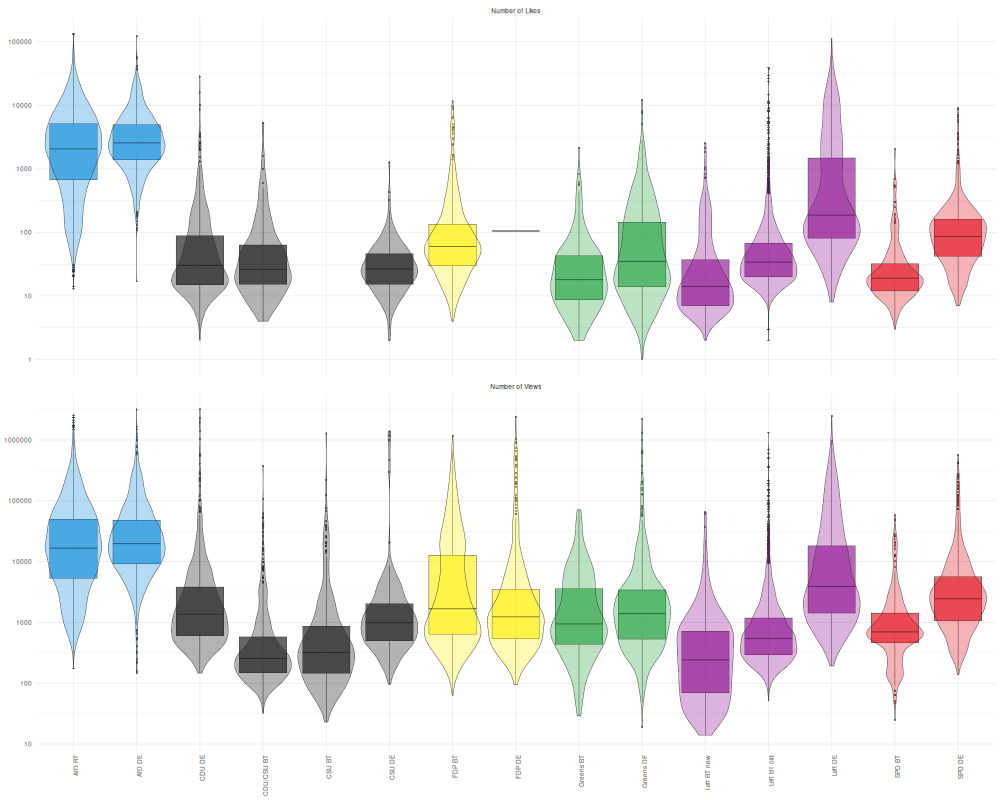

In [43]:
%%R -i df -w 1000 -h 800

df_plot <- df |>
   mutate(
      likes = video_likes + 1,
      views = video_views + 1,
) |>
pivot_longer(
   c(likes, views),
   names_to = "var",
   values_to = "val"
)

plot <- ggplot(df_plot, aes(x=channel, y=val, fill=channel)) +
   geom_boxplot(
        alpha=0.6,
        size=0.2,
        outlier.size = 0.85,
        outlier.stroke = 0.3,
        outlier.shape = 16
    ) +
   geom_violin(
        alpha=0.3,
        trim=T,
        scale="width",
        size = 0.2
    ) +
   scale_y_continuous(trans="log10", breaks=scales::breaks_log(n=8)) +
   scale_color_manual(values=cmap, aesthetics=c("color", "fill")) +
   theme_minimal(
      base_size = 8
   ) +
   theme(
      axis.text.x=element_text(angle=90, hjust=1),
      axis.ticks.x=element_blank(),
      axis.title.x=element_blank(),
      axis.title.y=element_blank(),
      legend.position = "none"
   ) +
   facet_wrap(
    ~var,
        ncol=1,
        scales="free_y",
        labeller = as_labeller(c(
            likes = "Number of Likes",
            views = "Number of Views"
        ))
    ) +
   ylab("log(10)")
plot

In [ ]:
%%R

options(warn = -1)
p <- here(r_out, "figures/view_count.jpg")
if (file.exists(p)) file.remove(p)

ggsave(
    p,
    plot,
    # device = cairo_ps,
    # fallback_resolution = 800,
    dpi = 900,
    units = "cm",
    width=9,
    height=12
)
options(warn = 0)

# Populism Amount Plot

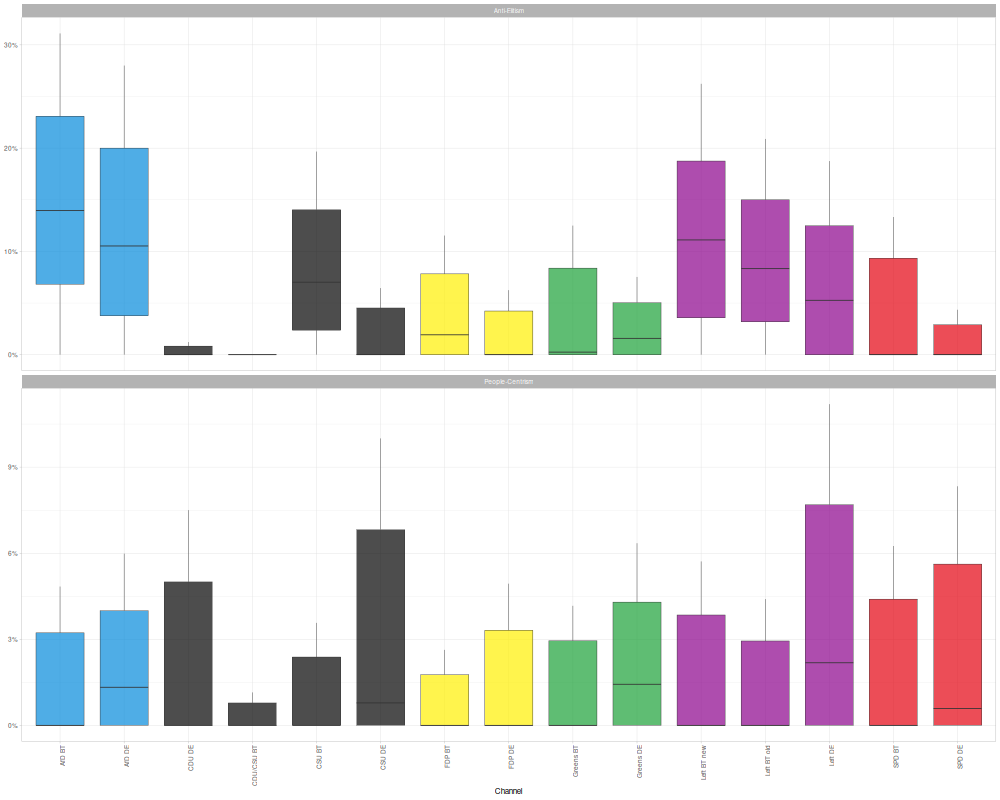

In [ ]:
%%R -i df -w 1000 -h 800

df_plot <- df |>
   mutate(
      elite = (n_elite / n_sents),
      pplcentr = (n_pplcentr / n_sents),
) |>
pivot_longer(
   c(elite, pplcentr),
   names_to = "var",
   values_to = "val"
)

plot <- ggplot(df_plot, aes(x=channel, y=val, fill=channel)) +
    geom_boxplot(
        size=0.2,
        alpha=0.7,
        outliers=F,
        coef=0.5
    ) +
   scale_color_manual(values=cmap, aesthetics=c("color", "fill")) +
   scale_y_continuous(labels = scales::label_percent()) +
   theme_minimal(
      base_size = 8
   ) +
   theme(
      axis.text.x=element_text(angle=90, hjust=1),
      axis.title.y=element_blank(),
      legend.position = "none"
   ) +
   xlab("Channel") +
   facet_wrap(
        ~var,
        ncol=1,
        scales="free_y",
        labeller = as_labeller(c(
            elite = "Anti-Elitism",
            pplcentr = "People-Centrism"
        ))
    )

plot

In [ ]:
%%R

options(warn = -1)
p <- here(r_out, "/figures/populism_per_party.jpg")
if (file.exists(p)) file.remove(p)

ggsave(
    p,
    plot,
    # device = cairo_ps,
    # fallback_resolution = 1200,
    dpi = 900,
    units = "cm",
    width=8,
    height=9.5
)
options(warn = 0)

# Anti-Elitism Over Time

In [27]:
df = (
    videos[["video_id", "video_datetime_upload", "channel", "party"]]
    .merge(sentences, on="video_id", how="left")
    .assign(date=lambda x: x["video_datetime_upload"].dt.normalize())
    .groupby(["party", "channel", "date"])
    .agg(
        elite=("elite", "mean"),
        pplcentr=("pplcentr", "mean"),
    )
    .reset_index(drop=False)
)

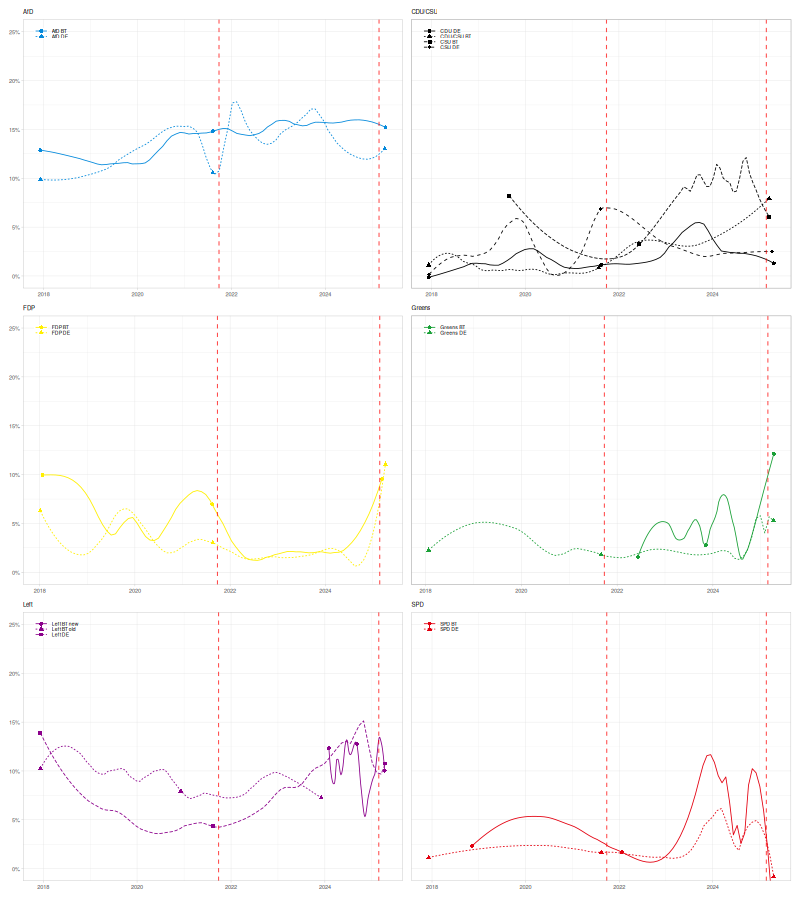

In [ ]:
%%R -i df -w 800 -h 900

PLOT_WIDTH <- 7
PLOT_HEIGHT <- 7

shape_values <- c(16, 17, 15, 18)


df_plot <- df |>
    mutate(
        date = as.Date(date)
    )

election_dates <- as.Date(c("2021-09-26", "2025-02-23"))
parties <- unique(df_plot$party)
plots <- list()

# Add this after geom_smooth():
stat_smooth_func <- function(
    mapping = NULL,
    data = NULL,
    geom = "point",
    position = "identity",
    ...,
    method = "loess",
    se = FALSE,
    n = 20,
    span = 0.3) {
  layer(
    data = data,
    mapping = mapping,
    stat = StatSmooth,
    geom = geom,
    position = position,
    show.legend = NA,
    inherit.aes = TRUE,
    params = list(method = method, se = se, n = n, span = span, ...))
}

for(i in seq_along(parties)) {
  p <- parties[i]
  party_data <- df_plot %>% filter(party == p)
  is_right_column <- i %% 2 == 0
  
  plots[[p]] <- ggplot(party_data, aes(linetype = channel, x = date, y = elite)) +
    geom_smooth(
        formula = y ~ x,
        method = "loess",
        se = FALSE,
        span = 0.3,
        color = pmap[[p]],
        size=0.4
    ) +
    stat_smooth_func(
        aes(shape = channel),
        method = "loess",
        span = 0.3,
        color = pmap[[p]],
        size = 1.5,
        n = 3,
        formula = y ~ x
    ) +
    scale_shape_manual(values = shape_values) +
    scale_y_continuous(labels = scales::label_percent()) +
    geom_vline(xintercept = election_dates, color = "red", linetype = "dashed", alpha = 0.7) +
    coord_cartesian(ylim = c(0, 0.25)) +
    labs(
        title = p,
        y = if(is_right_column) NULL else "% Anti-Elitism", 
        x = "Time") +
    theme_minimal(
        base_size = 7
    ) +
    theme(
      legend.position = c(0.02, 0.98),  # Top-left corner
      legend.justification = c(0, 1),
      legend.background = element_blank(),
      legend.title = element_blank(),
      legend.text = element_text(size = 5),
      legend.key.size = unit(0.1, "cm"),
      legend.key.width = unit(0.5, "cm"), 
      axis.title.y = element_blank(),
      axis.title.x = element_blank(),
      axis.text.y = if(is_right_column) element_blank() else element_text(),
      axis.ticks.y = if(is_right_column) element_blank() else element_line(),
      strip.text = element_text(size = 5),
      title = element_text(size = 5)
    ) +
    guides(
        shape = guide_legend(override.aes = list(size = 1.5)),
    )
}

# Combine plots
plot <- wrap_plots(plots, ncol = 2)
plot

In [ ]:
%%R

path <- here("reports", "figures", "elite_over_time.jpg")
if (file.exists(path)) file.remove(path)
ggsave(
    path,
    plot,
    units = "cm",
    dpi = 900,
    width = 8.5,
    height = 11
)

# People-Centrism Over Time

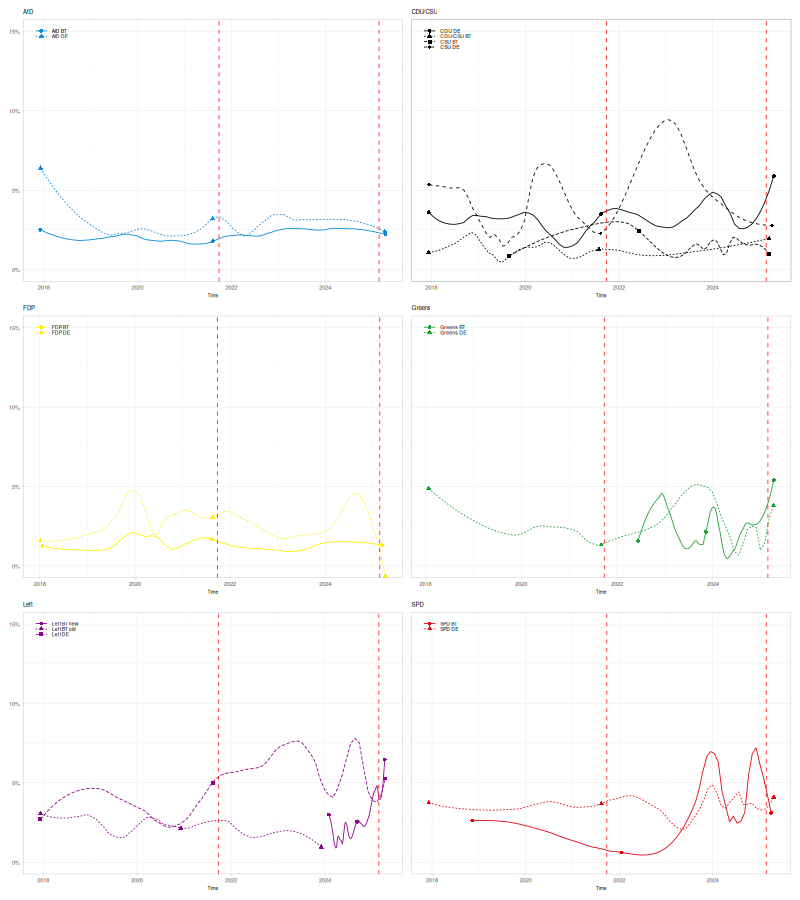

In [ ]:
%%R -i df -w 800 -h 900

df_plot <- df |>
    mutate(
        date = as.Date(date)
    )

election_dates <- as.Date(c("2021-09-26", "2025-02-23"))
parties <- unique(df_plot$party)
plots <- list()

# Add this after geom_smooth():
stat_smooth_func <- function(
    mapping = NULL,
    data = NULL,
    geom = "point",
    position = "identity",
    ...,
    method = "loess",
    se = FALSE,
    n = 20,
    span = 0.3) {
  layer(
    data = data,
    mapping = mapping,
    stat = StatSmooth,
    geom = geom,
    position = position,
    show.legend = NA,
    inherit.aes = TRUE,
    params = list(method = method, se = se, n = n, span = span, ...))
}

for(i in seq_along(parties)) {
  p <- parties[i]
  party_data <- df_plot %>% filter(party == p)
  is_right_column <- i %% 2 == 0
  
  plots[[p]] <- ggplot(party_data, aes(linetype = channel, x = date, y = pplcentr)) +
    geom_smooth(
        formula = y ~ x,
        method = "loess",
        se = FALSE,
        span = 0.3,
        color = pmap[[p]],
        size=0.4
    ) +
    stat_smooth_func(
        aes(shape = channel),
        method = "loess",
        span = 0.3,
        color = pmap[[p]],
        size = 1.5,
        n = 3,
        formula = y ~ x
    ) +
    scale_shape_manual(values = shape_values) +
    scale_y_continuous(labels = scales::label_percent()) +
    geom_vline(xintercept = election_dates, color = "red", linetype = "dashed", alpha = 0.7) +
    coord_cartesian(ylim = c(0, 0.15)) +
    labs(
        title = p,
        y = if(is_right_column) NULL else "% People-Centrism", 
        x = "Time") +
    theme_minimal(
        base_size = 7
    ) +
    theme(
      legend.position = c(0.02, 0.98),  # Top-left corner
      legend.justification = c(0, 1),
      legend.background = element_blank(),
      legend.title = element_blank(),
      legend.text = element_text(size = 5),
      legend.key.size = unit(0.1, "cm"),
      legend.key.width = unit(0.5, "cm"), 
      axis.title.y = element_blank(),
      axis.text.y = if(is_right_column) element_blank() else element_text(),
      axis.ticks.y = if(is_right_column) element_blank() else element_line(),
      strip.text = element_text(size = 5),
      title = element_text(size = 5)
    ) +
    guides(
        shape = guide_legend(override.aes = list(size = 1.5)),
    )
}

# Combine plots
plot <- wrap_plots(plots, ncol = 2)

plot

In [ ]:
%%R

path <- here("reports", "figures", "pplcentr_over_time.jpg")
if (file.exists(path)) file.remove(path)

ggsave(
    path,
    plot,
    units = "cm",
    dpi = 900,
    width = 8.5,
    height = 11
)